In [1]:
#forestfire
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

In [2]:
forest_df = pd.read_csv("../data/forestfires.csv")

In [3]:
print(forest_df.shape)
print(forest_df.columns)  
print(forest_df.dtypes)    
print(forest_df.head())

(517, 13)
Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='object')
X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0


In [4]:
print("Missing values:\n", forest_df.isnull().sum())
forest_df = forest_df.dropna()

Missing values:
 X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


In [5]:
forest_df = forest_df.drop_duplicates()

In [6]:
forest_df['month'] = forest_df['month'].str.strip().str.lower()
forest_df['day'] = forest_df['day'].str.strip().str.lower()

In [7]:
forest_df = pd.get_dummies(forest_df, columns=['month','day'], drop_first=True)

In [8]:
#Log transform the target variable (area), since it's highly skewed
forest_df['area'] = np.log1p(forest_df['area'])  

print("Forest Fire Dataset after preprocessing:\n", forest_df.head())
forest_df.shape


Forest Fire Dataset after preprocessing:
    X  Y  FFMC   DMC     DC  ISI  temp  RH  wind  rain  ...  month_may  \
0  7  5  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0  ...      False   
1  7  4  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0  ...      False   
2  7  4  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0  ...      False   
3  8  6  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2  ...      False   
4  8  6  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0  ...      False   

   month_nov  month_oct  month_sep  day_mon  day_sat  day_sun  day_thu  \
0      False      False      False    False    False    False    False   
1      False       True      False    False    False    False    False   
2      False       True      False    False     True    False    False   
3      False      False      False    False    False    False    False   
4      False      False      False    False    False     True    False   

   day_tue  day_wed  
0    False    False  
1     True    False  
2    Fal

(513, 28)

In [9]:
forest_df.describe()   

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000
mean,4.678363,4.300195,90.637427,110.989279,549.155166,9.023587,18.887524,44.348928,4.010526,0.021832,1.113081
std,2.320059,1.230925,5.540920,64.191013,247.724594,4.575543,5.828128,16.358803,1.796613,0.297107,1.397685
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,440.900000,6.400000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.500000,8.400000,19.300000,42.000000,4.000000,0.000000,0.431782
75%,7.000000,5.000000,92.900000,142.400000,713.900000,11.000000,22.800000,53.000000,4.900000,0.000000,2.024193
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,6.995620


In [10]:
forest_df.describe(include='bool') 

,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
count,513,513,513,513,513,513,513,513,513,513,513,513,513,513,513,513,513
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
freq,331,504,493,511,481,497,460,511,512,498,341,439,430,419,452,449,460


In [11]:
num_cols = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
cat_cols = [col for col in forest_df.columns if forest_df[col].dtype == 'bool']

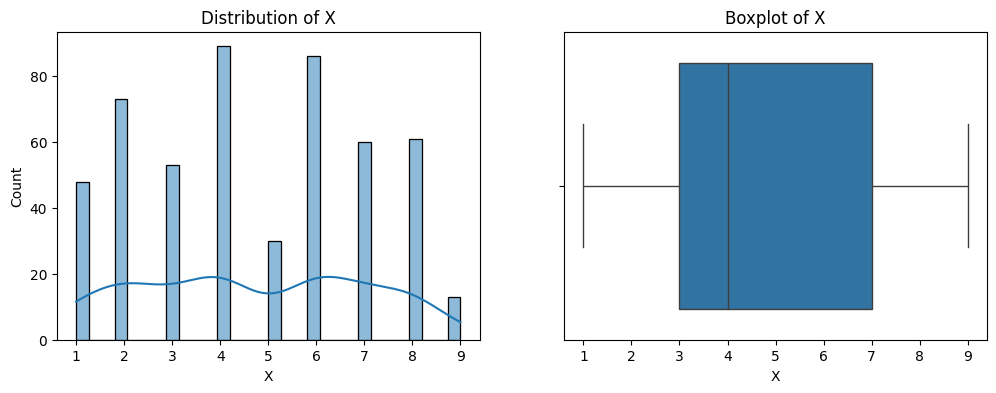

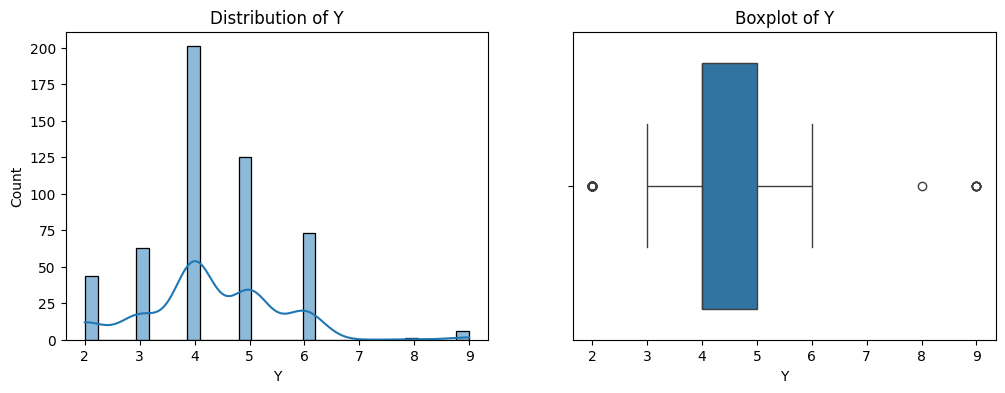

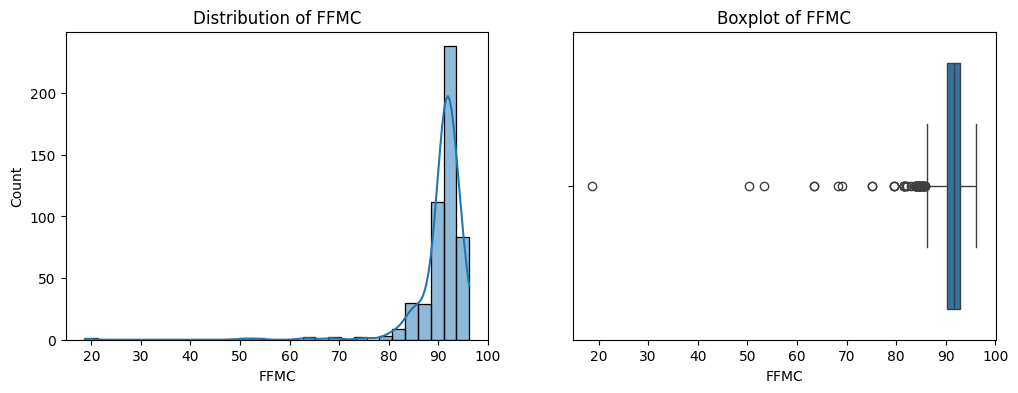

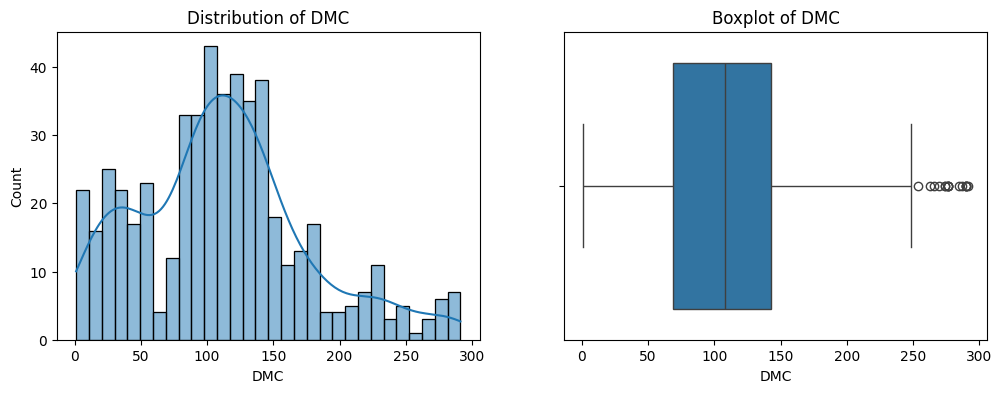

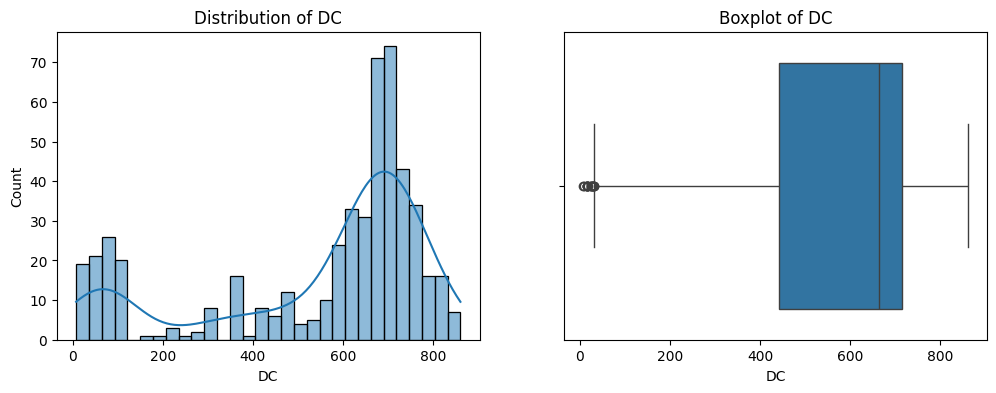

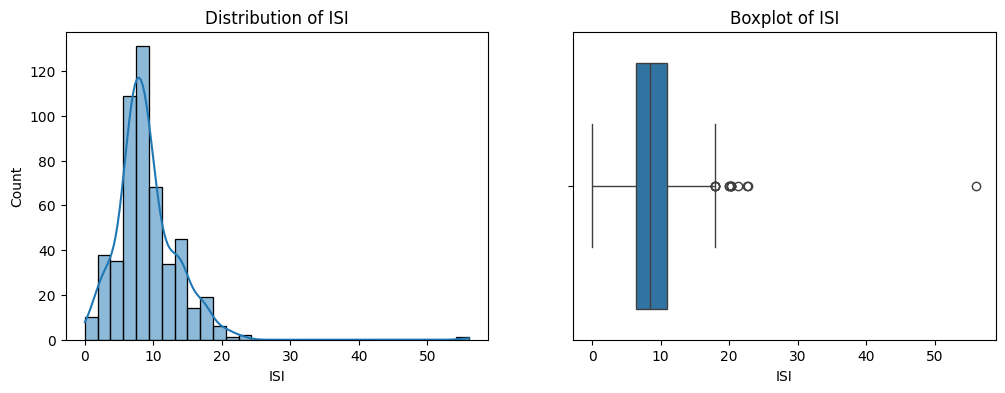

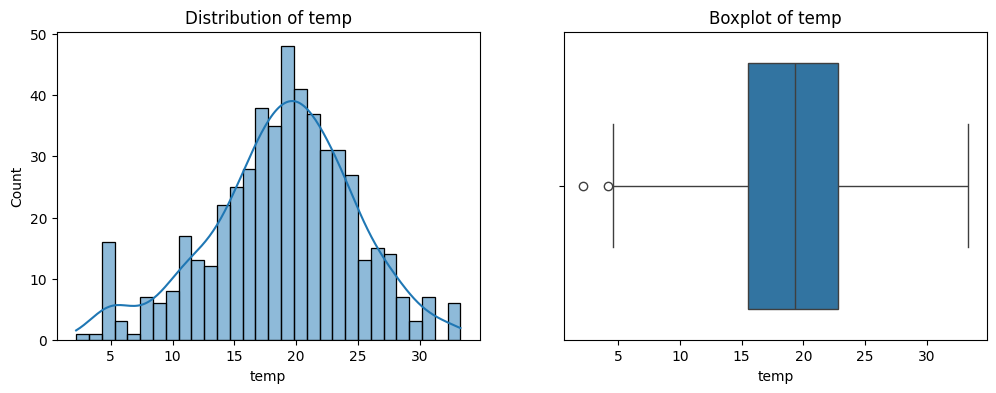

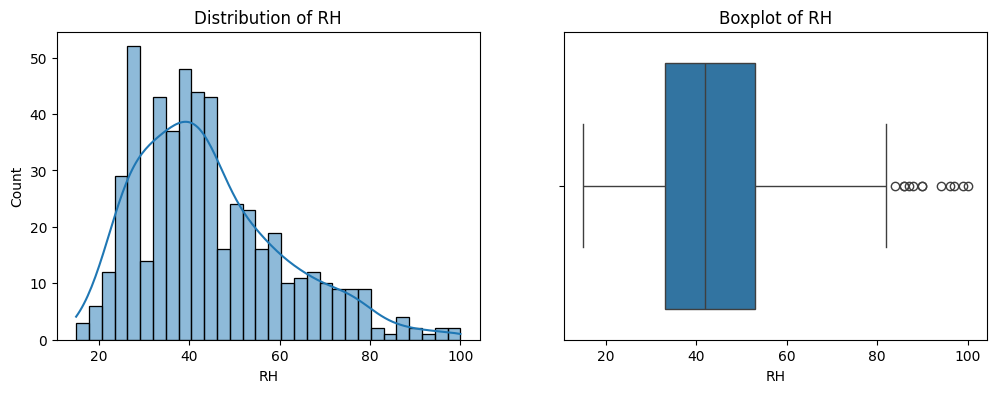

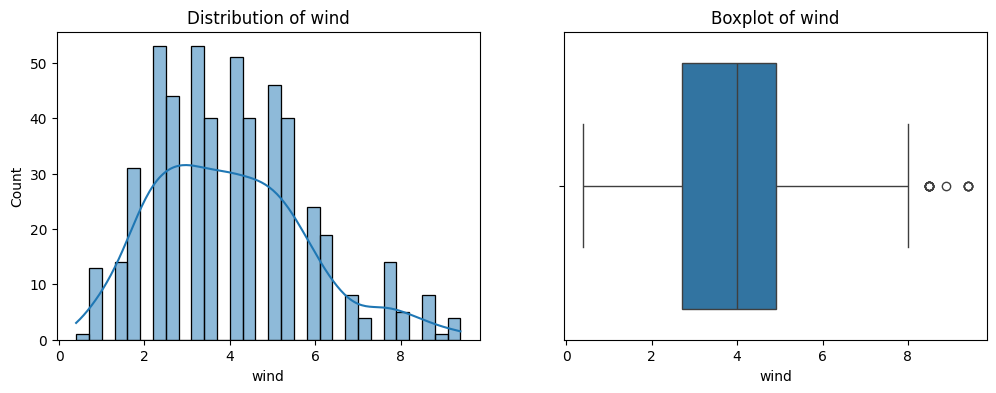

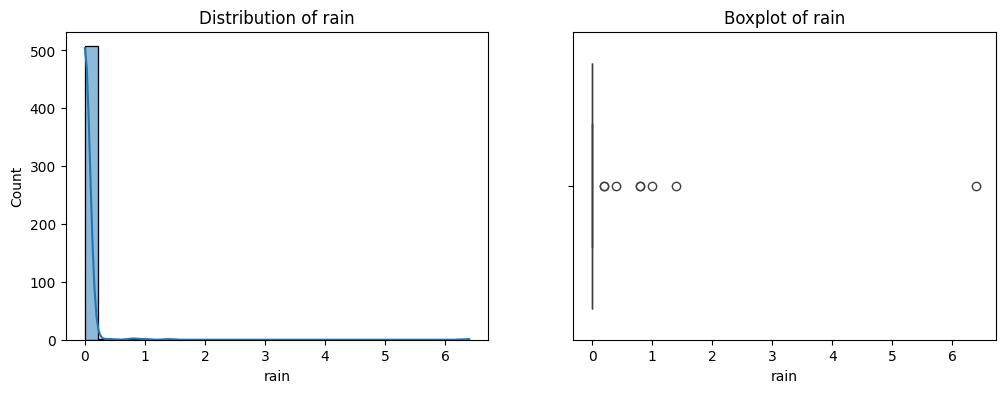

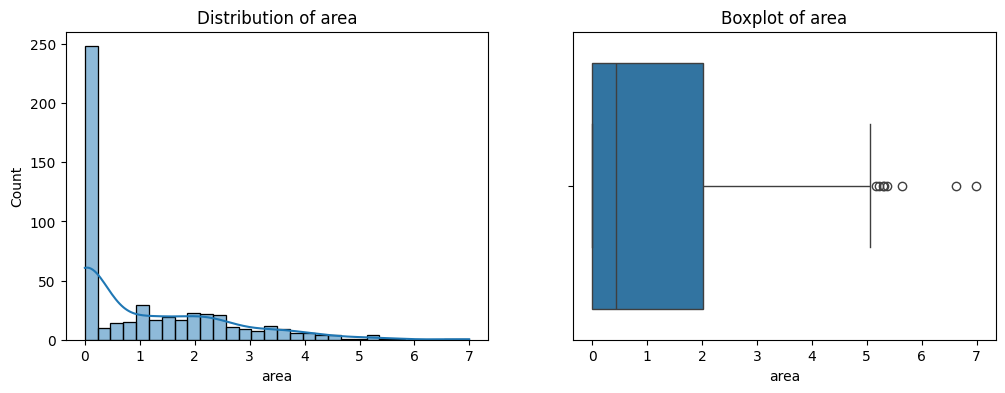

In [12]:
# --- Numerical Features ---
for col in num_cols:
    plt.figure(figsize=(12,4))
    
    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(forest_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=forest_df[col])
    plt.title(f"Boxplot of {col}")
    
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_840\420505640.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="viridis")


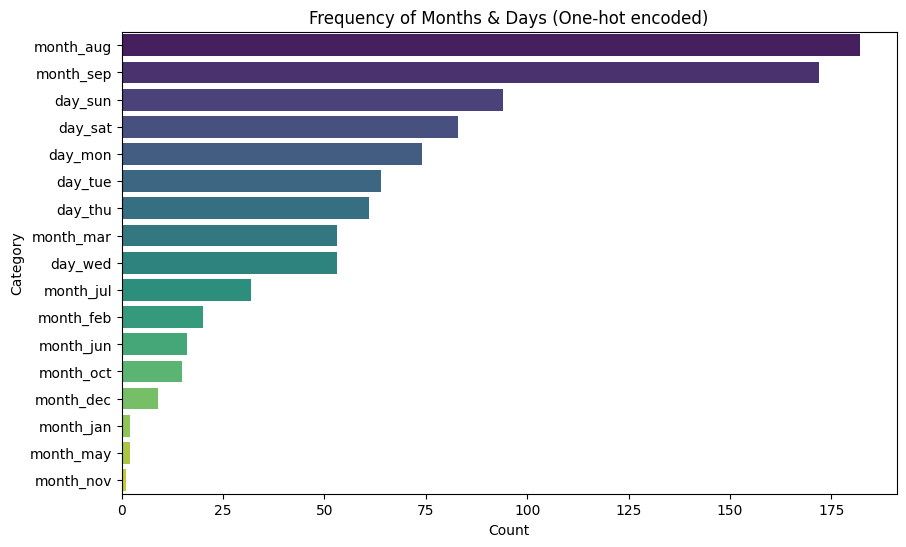

In [13]:
cat_counts = forest_df[cat_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="viridis")
plt.title("Frequency of Months & Days (One-hot encoded)")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

In [14]:
Q1 = forest_df[num_cols].quantile(0.25)
Q3 = forest_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

for col in num_cols:
    outliers = ((forest_df[col] < (Q1[col] - 1.5 * IQR[col])) | 
                (forest_df[col] > (Q3[col] + 1.5 * IQR[col])))
    outlier_count = outliers.sum()
    if outlier_count > 0:
        print(f"{col}: {outlier_count} outliers")
    else:
        print(f"{col}: No outliers")


X: No outliers
Y: 51 outliers
FFMC: 53 outliers
DMC: 17 outliers
DC: 17 outliers
ISI: 14 outliers
temp: 2 outliers
RH: 12 outliers
wind: 13 outliers
rain: 8 outliers
area: 8 outliers


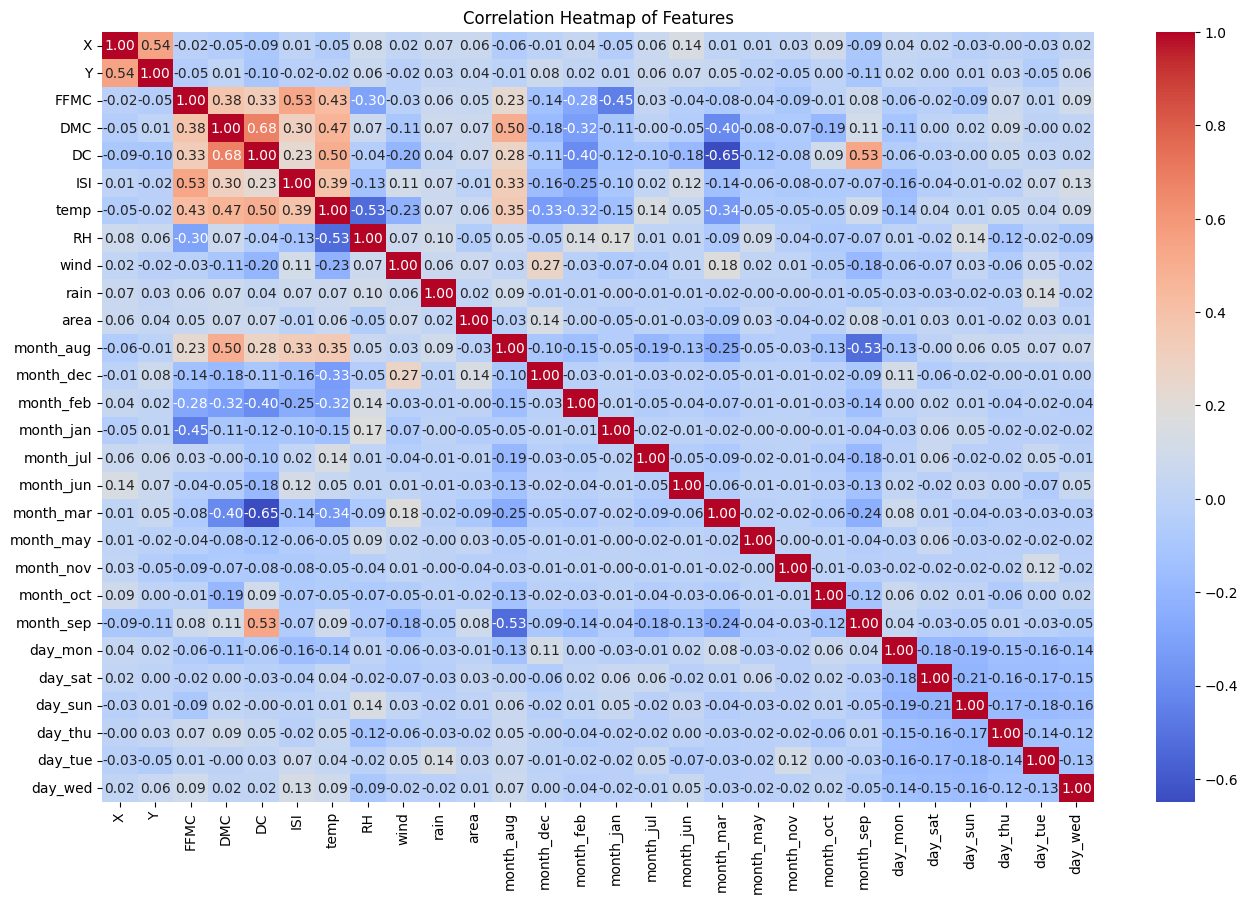

In [15]:
plt.figure(figsize=(16,10))
corr = forest_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features", fontsize=12)
plt.show()

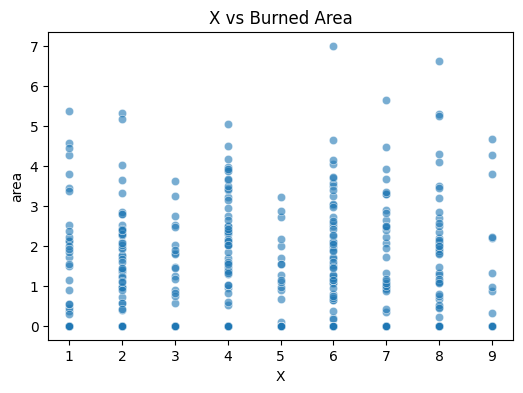

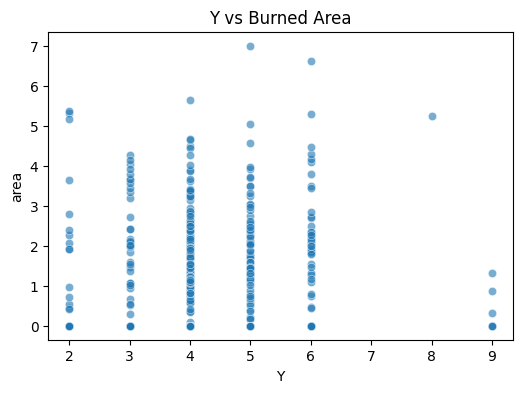

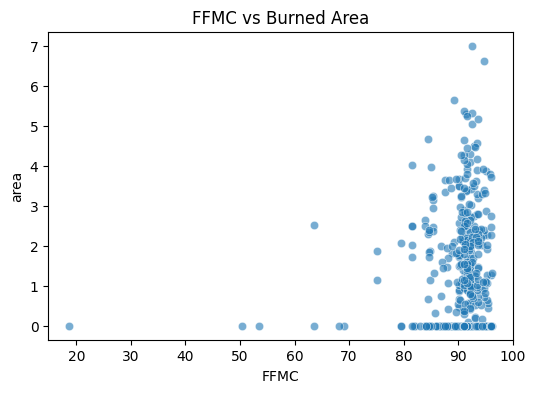

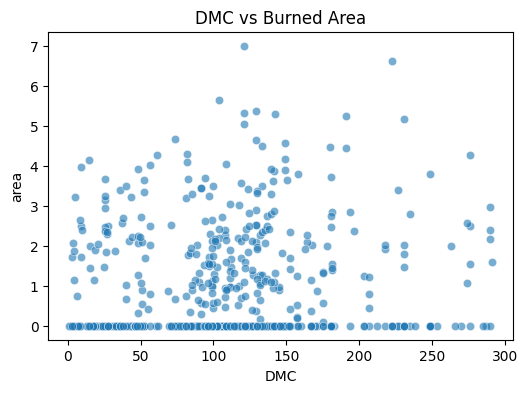

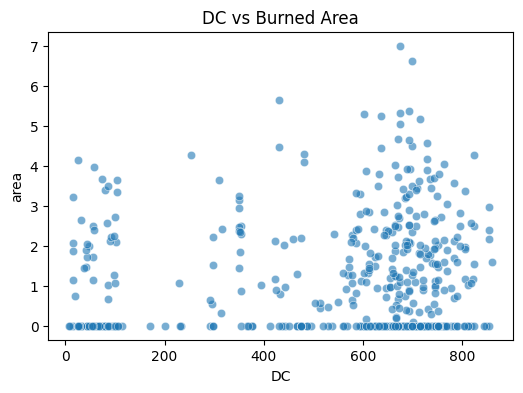

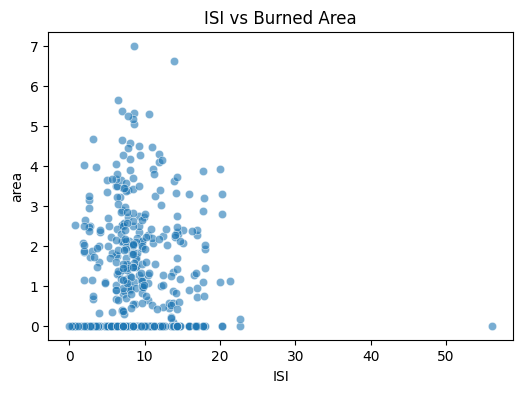

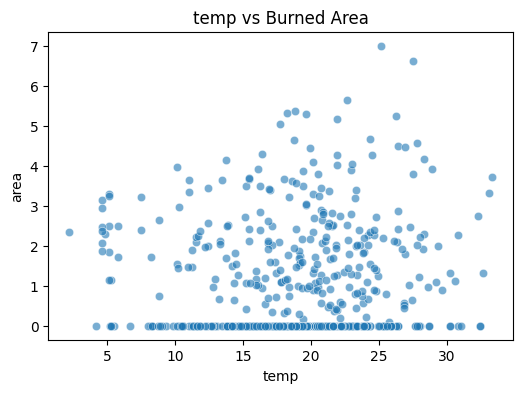

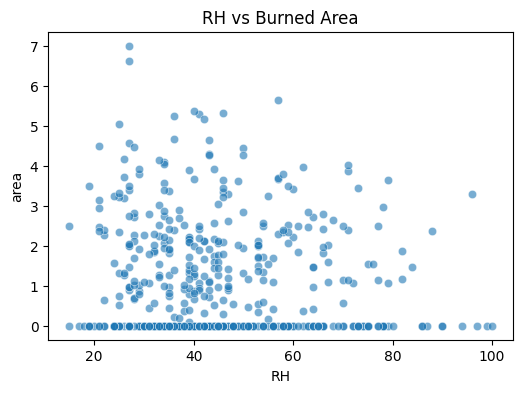

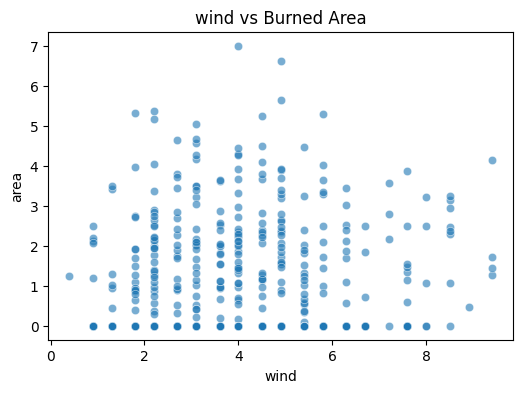

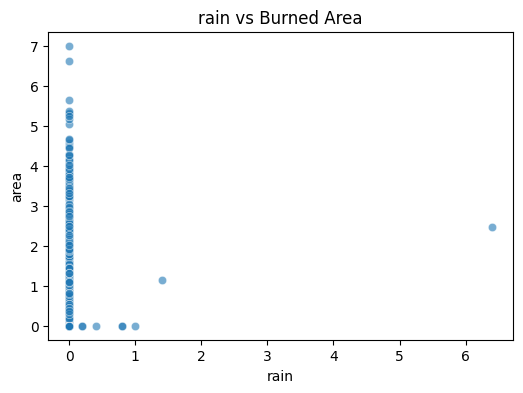

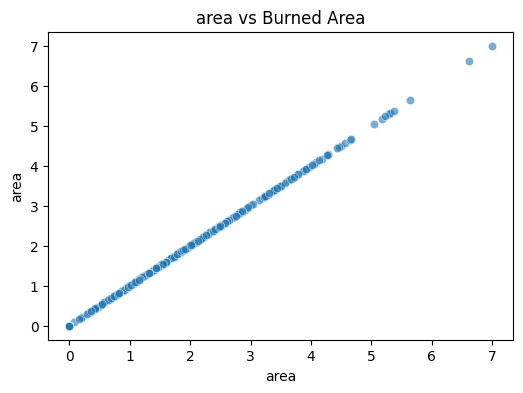

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=forest_df[col], y=forest_df["area"], alpha=0.6)
    plt.title(f"{col} vs Burned Area")
    plt.show()

In [29]:
#fire_nrt_M-C61_648697 (Satellite)
satellite_df = pd.read_csv("../data/fire_nrt_M-C61_648697.csv")

In [30]:
print(satellite_df.shape)
print(satellite_df.columns)  
print(satellite_df.dtypes)    
print(satellite_df.head())

(161028, 14)
Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight'],
      dtype='object')
latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence      int64
version        object
bright_t31    float64
frp           float64
daynight       object
dtype: object
   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0  47.85407  -53.09081      348.67  1.09   1.04  2025-08-05         5   
1  47.84950  -53.11857      326.28  1.09   1.04  2025-08-05         5   
2  47.82690  -53.13979      328.95  1.09   1.04  2025-08-05         5   
3  47.82461  -53.15363      313.53  1.09   1.04  2025-08-05         5   
4  47.84050  -53.11531      379.22  1.09   1.04  2025-08-05         5   

  satellite instr

In [31]:
print("Missing values:\n", satellite_df.isnull().sum())
satellite_df = satellite_df.dropna()

Missing values:
 latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
dtype: int64


In [32]:
satellite_df.describe()

,latitude,longitude,brightness,scan,track,acq_time,confidence,bright_t31,frp
count,161028.000000,161028.000000,161028.000000,161028.000000,161028.000000,161028.000000,161028.000000,161028.000000,161028.000000
mean,1.430574,11.252375,323.902385,1.615083,1.216650,1256.904985,66.292812,299.284777,45.400551
std,25.036712,55.441845,18.582960,0.794265,0.239694,474.926627,21.423150,7.564450,126.899078
min,-50.140670,-175.073880,300.000000,1.000000,1.000000,1.000000,0.000000,266.410000,0.000000
25%,-13.129220,13.584297,313.620000,1.060000,1.030000,1223.000000,54.000000,294.960000,10.400000
50%,-9.368445,21.047275,319.190000,1.280000,1.120000,1323.000000,68.000000,299.930000,18.860000
75%,-2.476675,29.011837,327.950000,1.850000,1.330000,1403.000000,81.000000,303.790000,39.560000
max,74.291110,179.320660,510.030000,4.820000,2.000000,2358.000000,100.000000,400.070000,6722.540000


In [33]:
satellite_df = satellite_df.drop_duplicates()

In [34]:
satellite_df['acq_date'] = pd.to_datetime(satellite_df['acq_date'], errors='coerce')

In [35]:
cat_cols = ['satellite', 'instrument', 'version', 'daynight']
for col in cat_cols:
    satellite_df[col] = satellite_df[col].astype('category')

In [36]:
satellite_df['confidence'] = satellite_df['confidence'].fillna(satellite_df['confidence'].median())
 # treat 0 as missing if needed

# 4️⃣ Drop duplicates
satellite_df = satellite_df.drop_duplicates()

# 5️⃣ Handle missing values
print(satellite_df.isnull().sum())
# Depending on % missing: drop rows or impute
satellite_df = satellite_df.dropna()

# 6️⃣ Feature Engineering
satellite_df['month'] = satellite_df['acq_date'].dt.month
satellite_df['year'] = satellite_df['acq_date'].dt.year
satellite_df['hour'] = (satellite_df['acq_time']//100) % 24  # Convert acq_time (HHMM) to hour

latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
dtype: int64


In [37]:
print(satellite_df.info())
print(satellite_df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   latitude    161028 non-null  float64       
 1   longitude   161028 non-null  float64       
 2   brightness  161028 non-null  float64       
 3   scan        161028 non-null  float64       
 4   track       161028 non-null  float64       
 5   acq_date    161028 non-null  datetime64[ns]
 6   acq_time    161028 non-null  int64         
 7   satellite   161028 non-null  category      
 8   instrument  161028 non-null  category      
 9   confidence  161028 non-null  int64         
 10  version     161028 non-null  category      
 11  bright_t31  161028 non-null  float64       
 12  frp         161028 non-null  float64       
 13  daynight    161028 non-null  category      
 14  month       161028 non-null  int32         
 15  year        161028 non-null  int32         
 16  ho

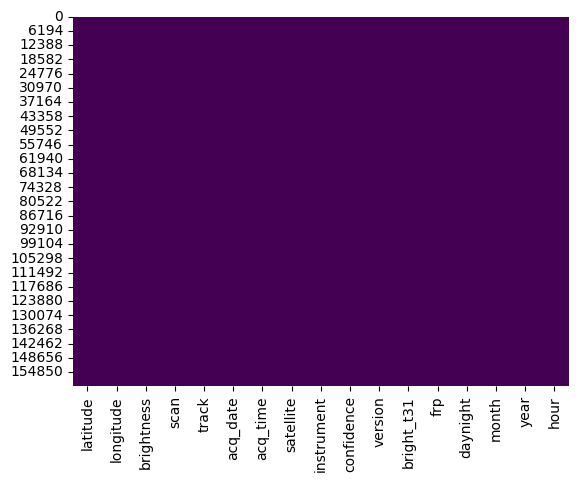

In [38]:
sns.heatmap(satellite_df.isnull(), cbar=False, cmap="viridis")
plt.show()


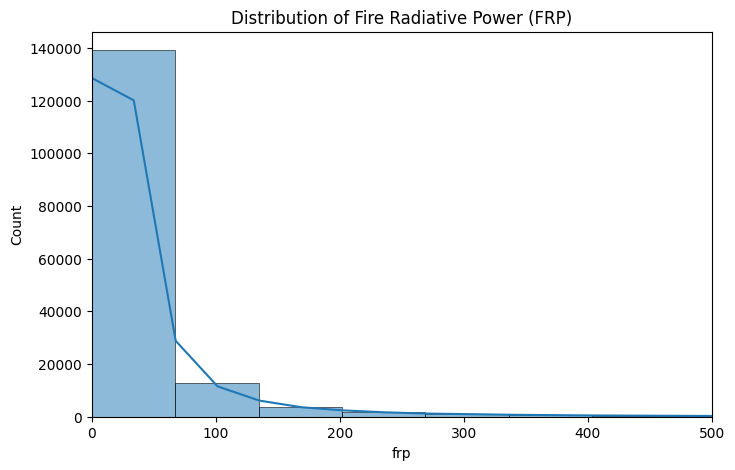

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(satellite_df['frp'], bins=100, kde=True)
plt.xlim(0, 500)  # zoom in (remove extreme tail)
plt.title("Distribution of Fire Radiative Power (FRP)")
plt.show()


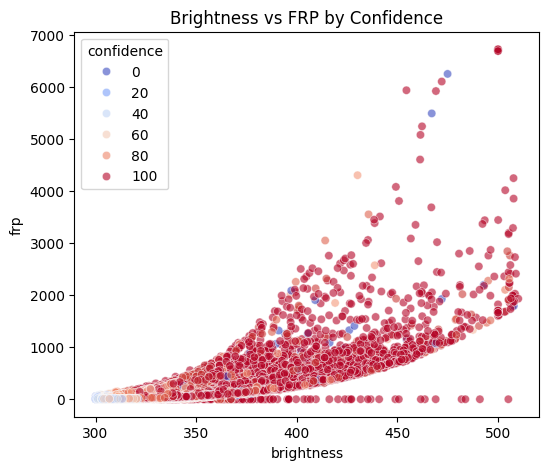

In [40]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=satellite_df, x='brightness', y='frp', hue='confidence', palette='coolwarm', alpha=0.6)
plt.title("Brightness vs FRP by Confidence")
plt.show()


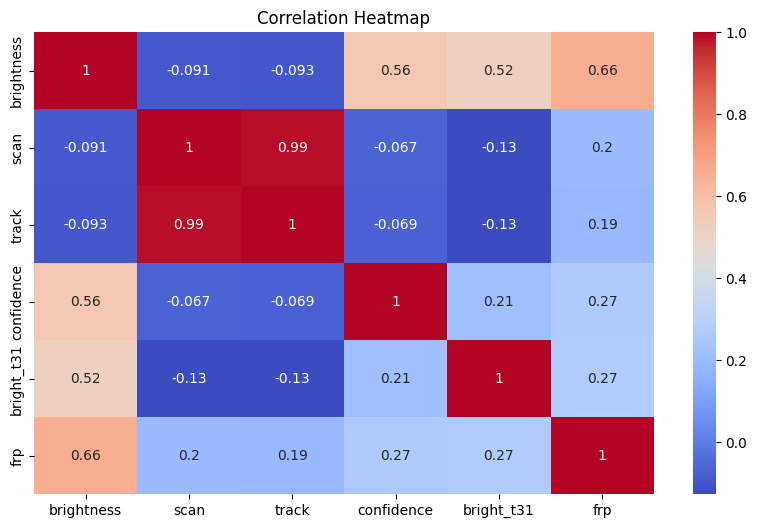

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(satellite_df[['brightness','scan','track','confidence','bright_t31','frp']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_840\1270710910.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=satellite_df, x='daynight', palette='Set2')


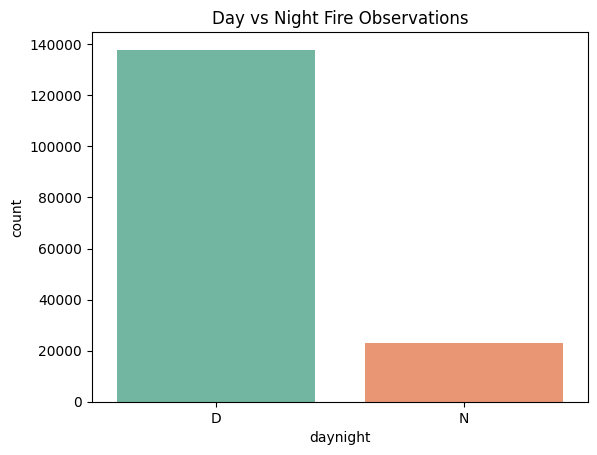

In [42]:
sns.countplot(data=satellite_df, x='daynight', palette='Set2')
plt.title("Day vs Night Fire Observations")
plt.show()


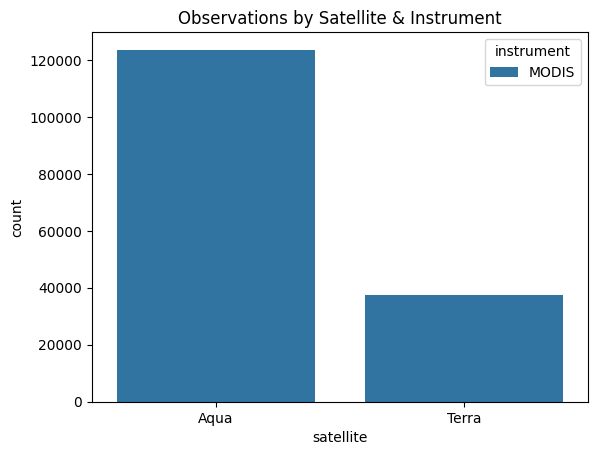

In [43]:
sns.countplot(data=satellite_df, x='satellite', hue='instrument')
plt.title("Observations by Satellite & Instrument")
plt.show()


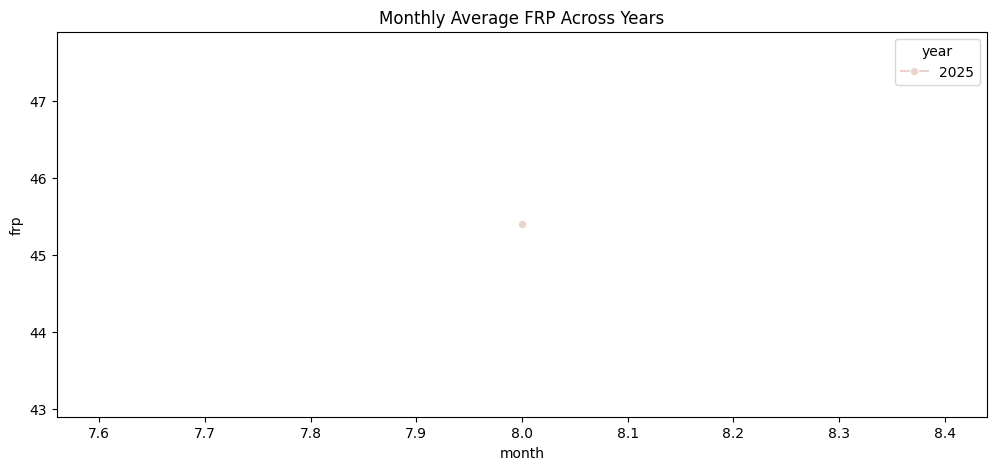

In [44]:
monthly_trend = satellite_df.groupby(['year','month'])['frp'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_trend, x='month', y='frp', hue='year', marker='o')
plt.title("Monthly Average FRP Across Years")
plt.show()


In [49]:
import folium

m = folium.Map(location=[satellite_df['latitude'].mean(), satellite_df['longitude'].mean()], zoom_start=2)
for _, row in satellite_df.sample(500).iterrows():  # sample for speed
    folium.CircleMarker(location=[row['latitude'], row['longitude']],
                        radius=2, color='red' if row['daynight']=="D" else 'blue',
                        fill=True).add_to(m)
m.save("fire_map.html")


  Using cached branca-0.8.1-py3-none-any.whl.metadata (1.5 kB)
Using cached branca-0.8.1-py3-none-any.whl (26 kB)

   ---------------------------------------- 0/3 [xyzservices]
   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
